# **Credit Limit Optizimation** -- EDA + ML Model

Combined notebook: exploratory data analysis followed by training and comparing 3 regression models (Linear Regression, XGBoost, LightGBM) to predict annual_medical_cost.

**Part 1 — EDA Part 2 — ML Model Training & Comparison**

## Part 1 - Exploratary Data Analysis (EDA)

In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [230]:
df = pd.read_csv("UCI_Credit_Card.csv.zip")
pd.set_option("display.max_columns", 50)
df.head(10)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
5,6,50000.0,1,1,2,37,0,0,0,0,0,0,64400.0,57069.0,57608.0,19394.0,19619.0,20024.0,2500.0,1815.0,657.0,1000.0,1000.0,800.0,0
6,7,500000.0,1,1,2,29,0,0,0,0,0,0,367965.0,412023.0,445007.0,542653.0,483003.0,473944.0,55000.0,40000.0,38000.0,20239.0,13750.0,13770.0,0
7,8,100000.0,2,2,2,23,0,-1,-1,0,0,-1,11876.0,380.0,601.0,221.0,-159.0,567.0,380.0,601.0,0.0,581.0,1687.0,1542.0,0
8,9,140000.0,2,3,1,28,0,0,2,0,0,0,11285.0,14096.0,12108.0,12211.0,11793.0,3719.0,3329.0,0.0,432.0,1000.0,1000.0,1000.0,0
9,10,20000.0,1,3,2,35,-2,-2,-2,-2,-1,-1,0.0,0.0,0.0,0.0,13007.0,13912.0,0.0,0.0,0.0,13007.0,1122.0,0.0,0


I loaded the UCI credit card dataset and checked the first few rows to understand the columns and the type of information available.

In [231]:
df.shape

(30000, 25)

From the shape, I can see that the dataset initially contains 30,000 customers and 25 columns. This gives me enough observations for building a classification model.

### **1. Data Preparation**

In [232]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

From the information, I can see that the dataset has 30,000 records and the columns do not have missing values at this stage. The data contains customer details, repayment history, bill amounts, payment amounts, and the default target.

In [233]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


The descriptive statistics help me understand the range and spread of the numerical variables. I can also see that credit limit and bill amounts vary a lot between customers.

### 2. Dropping the columns ID bescause it has 0 prediction value

In [234]:
df.drop("ID",axis = 1,inplace=True)

I removed the ID column because it is only an identifier and does not provide useful information for predicting whether a customer will default.

###  Fix the categorical value:
*   EDUCATION has invalid codes(0,4,5,6)

        *   converting the codes 0,5,6 into 4(others)

*   MARRIAGE also having the invalid codes(3,0)

        *   coverting the codes 3,0 as only 3(others)







In [235]:
df.EDUCATION.unique()

array([2, 1, 3, 5, 4, 6, 0])

In [236]:
df['EDUCATION'] = df['EDUCATION'].replace({0:4,5:4,6:4})

In [237]:
df.MARRIAGE.unique()

array([1, 2, 3, 0])

In [238]:
df['MARRIAGE'] = df['MARRIAGE'].replace({0:3})

the invalid marriage codes by grouping the value 0 into the 'others' category represented by 3. This makes the categorical values more consistent before modelling.

### 3.Checking for any null values

In [239]:
df.isnull().sum()

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64

checked all columns for missing values. The result shows 0 missing values, so I do not need to remove or fill missing records during EDA.

### 4. Check for duplicated values

In [240]:
df.drop_duplicates(inplace = True)
df.shape

(29965, 24)

After removing duplicate rows, the dataset is reduced from 30,000 to 29,965 rows. I removed 35 duplicate records so that the same customer record is not repeated in the analysis.

### 5. Target check

In [241]:
df['default.payment.next.month'].value_counts(normalize=True)*100

default.payment.next.month
0    77.874187
1    22.125813
Name: proportion, dtype: float64

The target is imbalanced: about 77.87% of customers did not default and 22.13% defaulted. Because the default class is smaller, It need to pay attention to recall, precision and F1-score instead of looking only at accuracy.

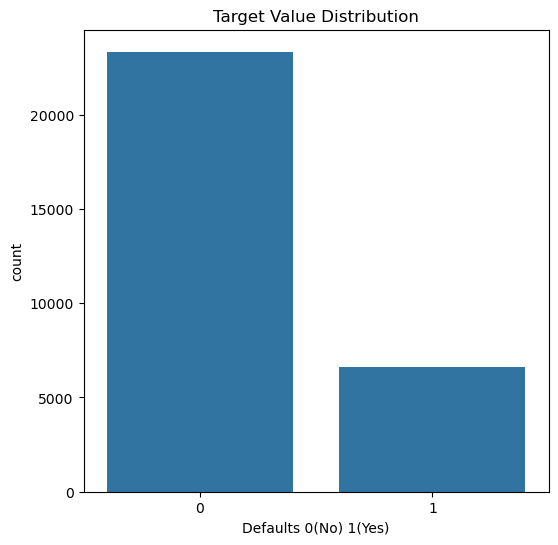

In [242]:
plt.figure(figsize=(6,6))
sns.countplot(x ='default.payment.next.month',data = df)
plt.title('Target Value Distribution')
plt.xlabel('Defaults 0(No) 1(Yes)')
plt.show()

The target distribution confirms that non-default customers are much more common than default customers. This class imbalance is important when I train and evaluate the classification models.

### 6.Distribution to Credit_Limit(LIMIT_BAL)

In [170]:
df['LIMIT_BAL'].describe()

count      29965.000000
mean      167442.005006
std       129760.135222
min        10000.000000
25%        50000.000000
50%       140000.000000
75%       240000.000000
max      1000000.000000
Name: LIMIT_BAL, dtype: float64

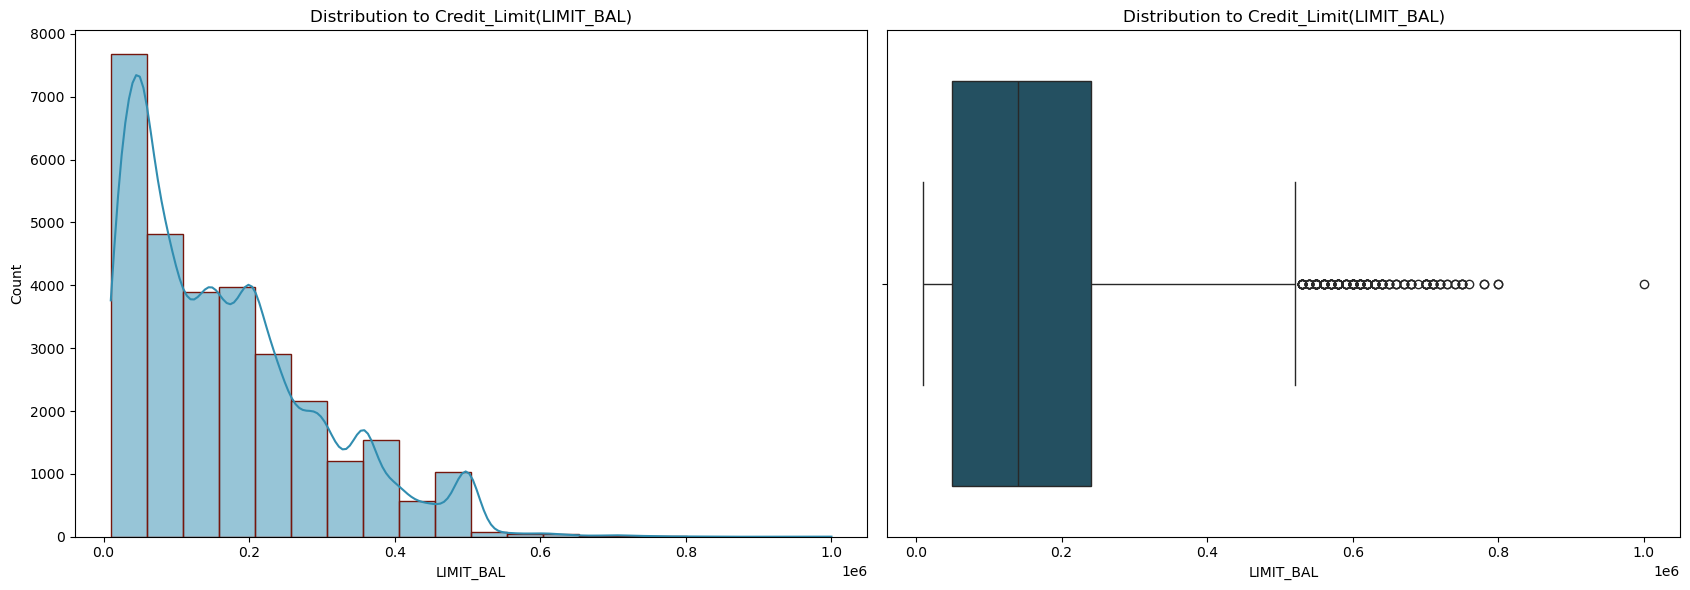

In [171]:
fig,axes = plt.subplots(1,2,figsize=(17,6))
sns.histplot(df['LIMIT_BAL'],bins=20,kde=True,ax=axes[0],color='#318DB0',edgecolor='#75170D')
axes[0].set_title('Distribution to Credit_Limit(LIMIT_BAL)')
sns.boxplot(data=df,x='LIMIT_BAL', ax=axes[1],color='#1A556B')
axes[1].set_title("Distribution to Credit_Limit(LIMIT_BAL)")
plt.tight_layout()
plt.show()

The credit-limit distribution is right-skewed, with some customers having much higher limits than most customers. The box plot also shows the presence of high-value observations.

### 7.Distribution of Age

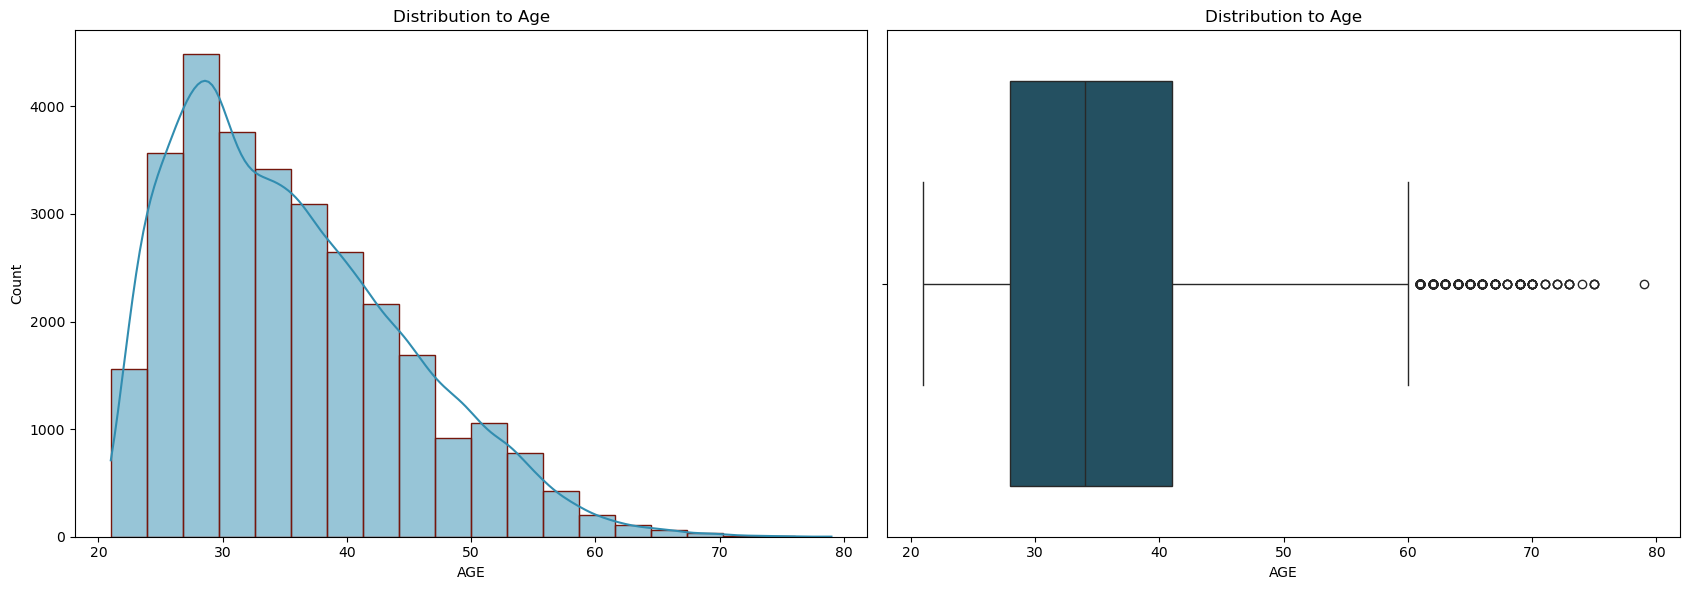

In [172]:
fig,axes = plt.subplots(1,2,figsize=(17,6))
sns.histplot(df['AGE'],bins=20,kde=True,ax=axes[0],color='#318DB0',edgecolor='#75170D')
axes[0].set_title('Distribution to Age')
sns.boxplot(data=df,x='AGE', ax=axes[1],color='#1A556B')
axes[1].set_title("Distribution to Age")
plt.tight_layout()
plt.show()

The age distribution shows that most customers are in the young-to-middle adult range. There are also some older customers, but the majority are concentrated around the main age range.

### 8. Repayment Status of Two Months

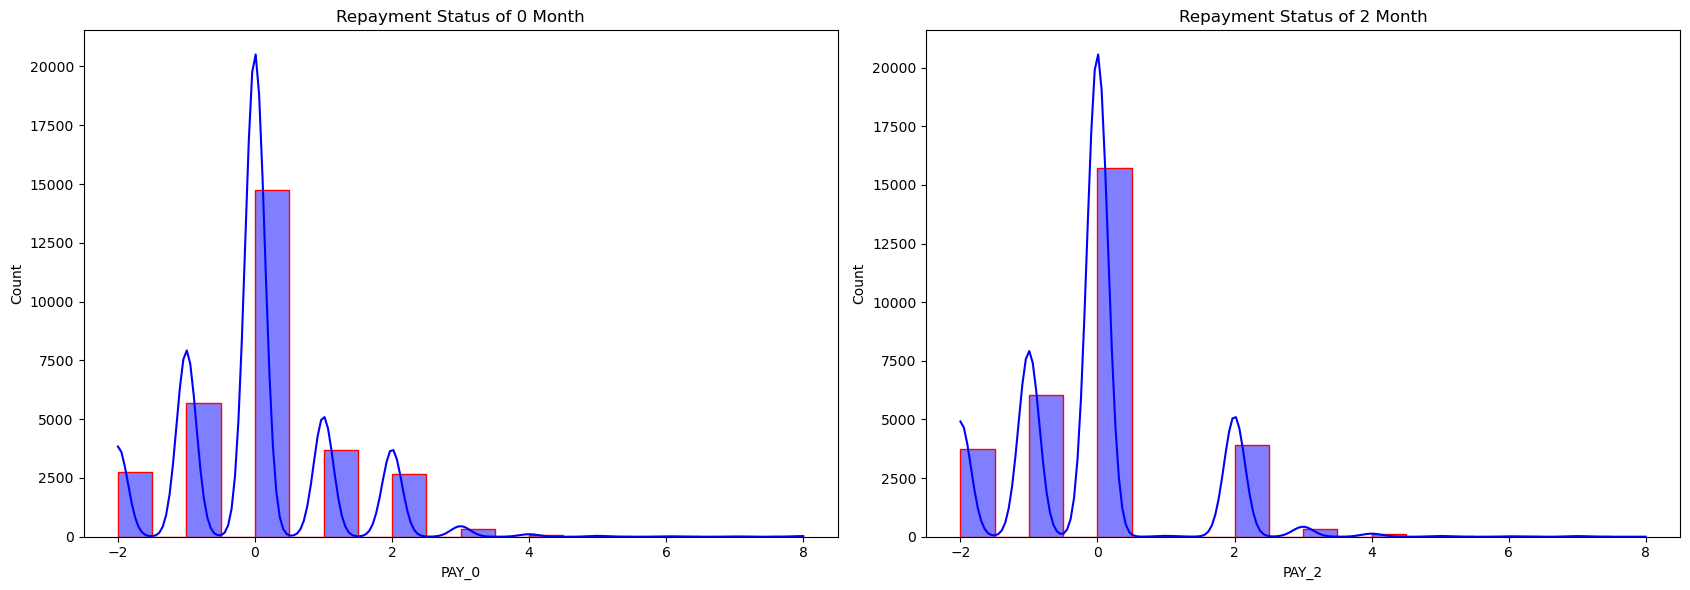

In [173]:
fig,axes = plt.subplots(1,2,figsize=(17,6))
sns.histplot(df['PAY_0'],bins=20,kde=True,ax=axes[0],color='blue',edgecolor='red')
axes[0].set_title('Repayment Status of 0 Month')
sns.histplot(df['PAY_2'],bins=20,kde=True,ax=axes[1],color='blue',edgecolor='red')
axes[1].set_title("Repayment Status of 2 Month")
plt.tight_layout()
plt.show()

The repayment-status distributions show that most customers have low or no payment delay, while a smaller group has larger delays. I will use these repayment variables because they can be useful indicators of default risk.

### 1.Credit Limit vs Default Value

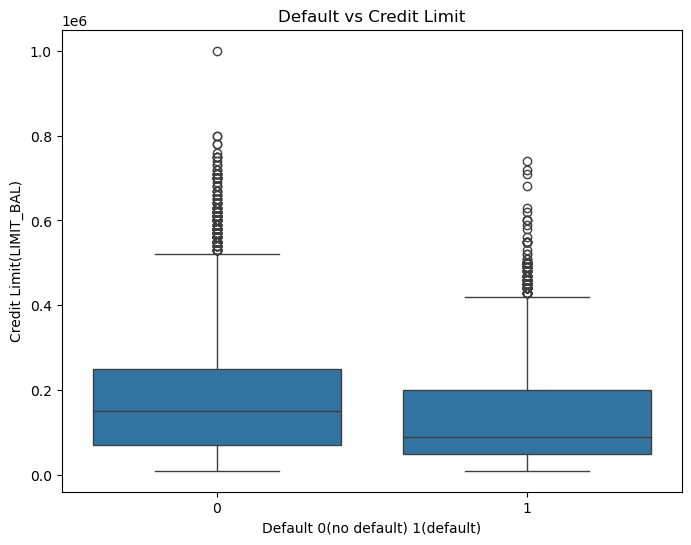

In [174]:
plt.figure(figsize=(8,6))
sns.boxplot(data = df, x = df['default.payment.next.month'],y = df['LIMIT_BAL'])
plt.title('Default vs Credit Limit')
plt.xlabel('Default 0(no default) 1(default)')
plt.ylabel('Credit Limit(LIMIT_BAL)')
plt.show()

From this comparison, I can see a difference in credit limits between default and non-default groups. However, credit limit alone is not enough to decide risk, so I will combine it with repayment and payment behaviour.

In [175]:
df['PAY_0'].value_counts()

PAY_0
 0    14737
-1     5682
 1     3667
-2     2750
 2     2666
 3      322
 4       76
 5       26
 8       19
 6       11
 7        9
Name: count, dtype: int64

### 9.Default vs Repayment Month (0_Month)

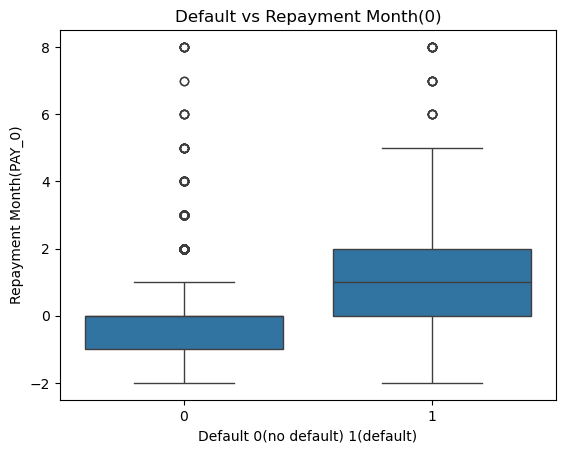

In [176]:
sns.boxplot(data = df, x = df['default.payment.next.month'], y = df['PAY_0'])
plt.title('Default vs Repayment Month(0)')
plt.xlabel('Default 0(no default) 1(default)')
plt.ylabel('Repayment Month(PAY_0)')
plt.show()

The box plot shows that customers who default tend to have higher repayment-delay values. This suggests that recent payment behaviour is an important signal for predicting default.

### 10.Correlation Heatmap

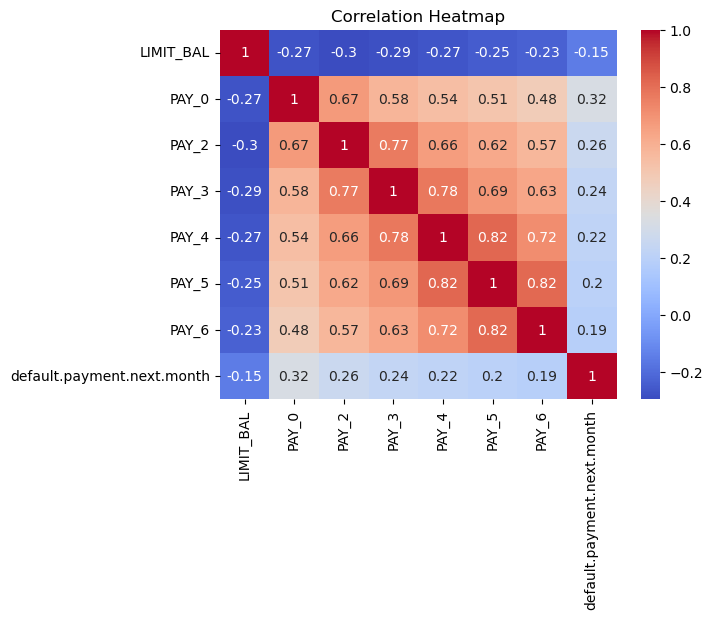

In [177]:
sns.heatmap(df[['LIMIT_BAL','PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6','default.payment.next.month']].corr(),annot=True,fmt='.2g',cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

The correlation heatmap shows that PAY_0 has the strongest positive relationship with default at about 0.32. LIMIT_BAL has a negative relationship of about -0.15, while the PAY variables are also correlated with each other because they describe repayment history over different months.

# **FEATURE ENGINEERING**

In [180]:
df_ml = df.copy()

df_ml['Total_delay_Months'] = (
    (df_ml['PAY_0'] > 0).astype(int) +
    (df_ml['PAY_2'] > 0).astype(int) +
    (df_ml['PAY_3'] > 0).astype(int) +
    (df_ml['PAY_4'] > 0).astype(int) +
    (df_ml['PAY_5'] > 0).astype(int) +
    (df_ml['PAY_6'] > 0).astype(int)
)
df_ml['max_delay'] = df_ml[
    ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
].max(axis=1)

df_ml['Payment_Ratio'] = (
    df_ml['PAY_AMT1'] /
    (df_ml['BILL_AMT1'].abs() + 1)
)

df_ml['Credit_Utilization'] = (
    df_ml['BILL_AMT1'] /
    (df_ml['LIMIT_BAL'] + 1)
)

print("New dataset shape:", df_ml.shape)

New dataset shape: (29965, 28)


created additional features from the repayment and payment information. Total delay, maximum delay, payment ratio and credit utilization are intended to summarize customer behaviour in a way that can help the model identify risk patterns.

# Part 2 - Model Training and Comparsion

In [286]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# 1.Assigning Features Vaiable and Target variable

In [243]:
X = df_ml.drop(
    columns=['default.payment.next.month']
)

y = df_ml['default.payment.next.month']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nNumber of features:", len(X.columns))

X shape: (29965, 27)
y shape: (29965,)

Number of features: 27


separated the input features from the target variable. I now have 27 features for predicting whether the customer will default in the next month.

### 2.Train Test and Spilt

In [244]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (23972, 27)
X_test : (5993, 27)
y_train: (23972,)
y_test : (5993,)


split the data into 80% training and 20% testing data and used stratification so that the default and non-default proportions remain similar in both sets.

# 3. Feature Scaling Process in Pipeline

In [245]:
logistic_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

In [246]:
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

In [247]:
xgb_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.7,
        colsample_bytree=1.0,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

print(" All Three pipelines created successfully.")

 All Three pipelines created successfully.


 created three model pipelines: Logistic Regression, Random Forest and XGBoost. The pipelines also handle missing values, and scaling is applied where it is useful for the model.

### 3. Training the Model

In [250]:
logistic_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)


print("Logistic Regression training completed.")
print("Random Forest training completed.")
print("XGBoost training completed.")

Logistic Regression training completed.
Random Forest training completed.
XGBoost training completed.


trained all three models on the training data. Now I can compare their performance on the same unseen test data.

### 4. Evaluate all models

In [252]:
def evaluate_model(model, x_test, y_test, model_name):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print(f"\n{'='*50}")
    print(model_name)
    print(f"{'='*50}")

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': roc_auc
    }

In [253]:
results = []

results.append(
    evaluate_model(
        logistic_pipeline,
        X_test,
        y_test,
        "Logistic Regression"
    )
)

results.append(
    evaluate_model(
        rf_pipeline,
        X_test,
        y_test,
        "Random Forest"
    )
)

results.append(
    evaluate_model(
        xgb_pipeline,
        X_test,
        y_test,
        "XGBoost"
    )
)


Logistic Regression
Accuracy : 0.7449
Precision: 0.4441
Recall   : 0.6086
F1 Score : 0.5135
ROC-AUC  : 0.7526

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      4667
           1       0.44      0.61      0.51      1326

    accuracy                           0.74      5993
   macro avg       0.66      0.70      0.67      5993
weighted avg       0.78      0.74      0.76      5993


Random Forest
Accuracy : 0.8109
Precision: 0.6361
Recall   : 0.3401
F1 Score : 0.4432
ROC-AUC  : 0.7630

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.94      0.89      4667
           1       0.64      0.34      0.44      1326

    accuracy                           0.81      5993
   macro avg       0.74      0.64      0.66      5993
weighted avg       0.79      0.81      0.79      5993


XGBoost
Accuracy : 0.8195
Precision: 0.6784
Recall   : 0.3499
F1 Score : 0.4617
R

In [254]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.744869,0.444139,0.608597,0.513522,0.752576
1,Random Forest,0.810946,0.636107,0.340121,0.443243,0.763024
2,XGBoost,0.819456,0.678363,0.349925,0.461692,0.776751


From the comparison, XGBoost gives the highest ROC-AUC of about 0.777, followed by Random Forest and Logistic Regression. I selected XGBoost as the best model because ROC-AUC is useful for comparing how well the model separates default and non-default customers.

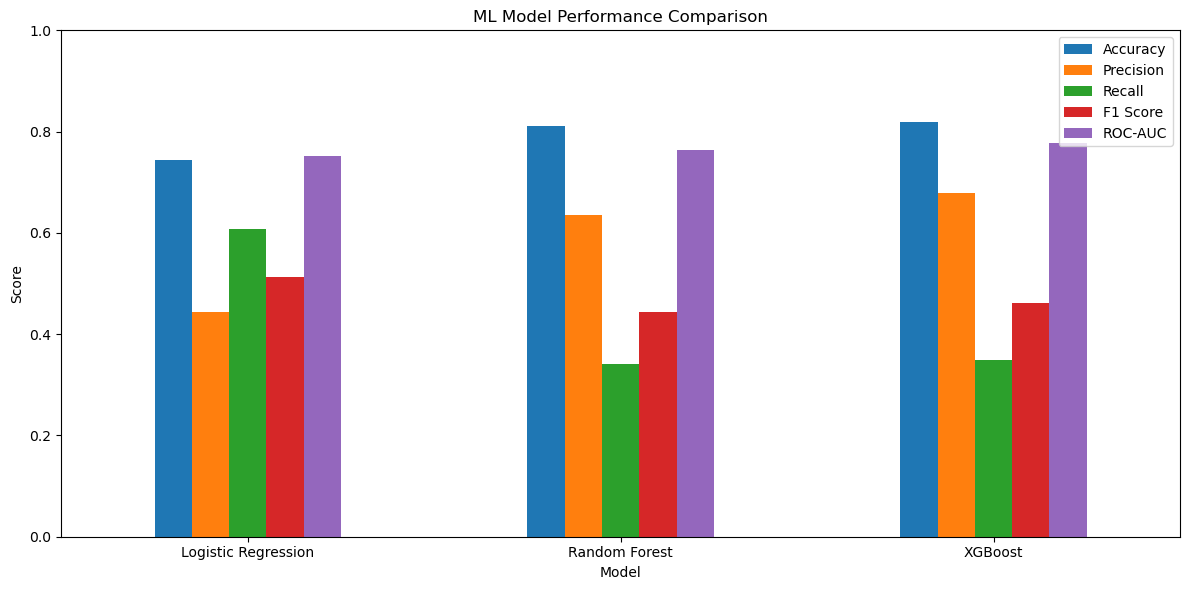

In [255]:
results_plot = results_df.set_index('Model')

results_plot.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('ML Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### 5. Finding Best Model

In [256]:
best_model_name = results_df.loc[
    results_df['ROC-AUC'].idxmax(),
    'Model'
]

print("Best model based on ROC-AUC:", best_model_name)

Best model based on ROC-AUC: XGBoost


Based on ROC-AUC, XGBoost is the best-performing model among the three models tested, so I will tune XGBoost further.

In [1]:
print(results_df.sort_values(
    by='ROC-AUC',
    ascending=False,
    ignore_index=True
))

NameError: name 'results_df' is not defined

### 6. XGBoost Hyperparameter Tunning

In [258]:
from sklearn.model_selection import RandomizedSearchCV

In [259]:
xgb_params = {
    'model__n_estimators': [200, 300, 500],
    'model__max_depth': [3, 4, 5, 6],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("\nBest parameters:")
print(xgb_search.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(xgb_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters:
{'model__subsample': 0.7, 'model__n_estimators': 500, 'model__max_depth': 4, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.8}

Best cross-validation ROC-AUC:
0.7889965127808731


I used RandomizedSearchCV with 5-fold cross-validation to search for better XGBoost parameters. The best combination uses 500 estimators, max depth 4, learning rate 0.01, subsample 0.7 and column sampling 0.8.

### 7.Evaluate Tunned XGBoost

In [261]:
best_xgb = xgb_search.best_estimator_

y_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]

# Default threshold = 0.50 for now
y_pred_tuned = (y_prob_tuned >= 0.50).astype(int)

print("Tuned XGBoost Results")
print("=" * 40)

print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall   :", recall_score(y_test, y_pred_tuned))
print("F1 Score :", f1_score(y_test, y_pred_tuned))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

Tuned XGBoost Results
Accuracy : 0.8177874186550976
Precision: 0.6735905044510386
Recall   : 0.34238310708898945
F1 Score : 0.454
ROC-AUC  : 0.7783278085178791

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4667
           1       0.67      0.34      0.45      1326

    accuracy                           0.82      5993
   macro avg       0.75      0.65      0.67      5993
weighted avg       0.80      0.82      0.79      5993



After tuning, XGBoost gives a ROC-AUC of about 0.778 at the default 0.50 threshold. The recall is still relatively low, so next checked different probability thresholds.

### 8.Threshold Analysis

In [262]:
thresholds = np.arange(0.10, 0.71, 0.05)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_tuned >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    threshold_results.append({
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.10,0.289328,0.905732,0.438561
1,0.15,0.347082,0.780543,0.480501
2,0.20,0.419263,0.669683,0.515679
3,0.25,0.482843,0.594268,0.532792
4,0.30,0.537358,0.536953,0.537156
5,0.35,0.584746,0.468326,0.520101
6,0.40,0.624862,0.428356,0.508277
7,0.45,0.650190,0.386878,0.485106
8,0.50,0.673591,0.342383,0.454000
9,0.55,0.698206,0.322775,0.441465


The threshold results show the trade-off between precision and recall. At a lower threshold, the model catches more default customers but also produces more false positives.

In [263]:
best_threshold = threshold_df.loc[
    threshold_df['F1 Score'].idxmax(),
    'Threshold'
]

print("Best threshold:", best_threshold)

Best threshold: 0.30000000000000004


The best F1-score is obtained at a threshold of 0.30. I use this threshold because it gives a better balance between precision and recall than the default 0.50 threshold.

### 8. Final Prediction

In [265]:
final_threshold = 0.30

y_pred_final = (
    y_prob_tuned >= final_threshold
).astype(int)

print("Final threshold:", final_threshold)

print("\nAccuracy :", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall   :", recall_score(y_test, y_pred_final))
print("F1 Score :", f1_score(y_test, y_pred_final))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_tuned))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_final
    )
)

Final threshold: 0.3

Accuracy : 0.7952611379943267
Precision: 0.5373584905660377
Recall   : 0.5369532428355958
F1 Score : 0.5371557902678235
ROC-AUC  : 0.7783278085178791

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      4667
           1       0.54      0.54      0.54      1326

    accuracy                           0.80      5993
   macro avg       0.70      0.70      0.70      5993
weighted avg       0.80      0.80      0.80      5993



After using the 0.30 threshold, the model gives about 0.54 precision and 0.54 recall, with an F1-score of about 0.54. This gives a more balanced result for identifying default customers.

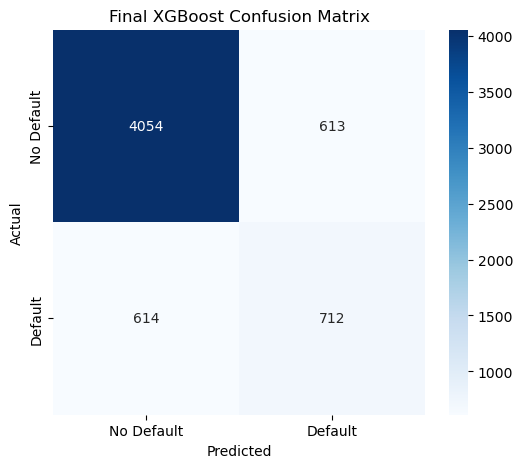

In [266]:
cm = confusion_matrix(
    y_test,
    y_pred_final
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Default', 'Default'],
    yticklabels=['No Default', 'Default']
)

plt.title('Final XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

The confusion matrix helps me see the number of correct and incorrect predictions for both classes. It is useful for checking how well the final threshold identifies actual default cases.

### 9. Final Feature Prediction

In [267]:
xgb_model = best_xgb.named_steps['model']

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

               Feature  Importance
5                PAY_0    0.304084
24           max_delay    0.227047
23  Total_delay_Months    0.127231
6                PAY_2    0.026220
17            PAY_AMT1    0.021708
18            PAY_AMT2    0.019955
11           BILL_AMT1    0.019651
20            PAY_AMT4    0.018063
0            LIMIT_BAL    0.017567
7                PAY_3    0.017324
26  Credit_Utilization    0.017212
19            PAY_AMT3    0.016708
10               PAY_6    0.015113
22            PAY_AMT6    0.013357
9                PAY_5    0.013172
15           BILL_AMT5    0.012613
12           BILL_AMT2    0.011569
2            EDUCATION    0.011385
8                PAY_4    0.010928
25       Payment_Ratio    0.010911
3             MARRIAGE    0.010715
1                  SEX    0.010297
14           BILL_AMT4    0.010111
21            PAY_AMT5    0.009635
16           BILL_AMT6    0.009528
13           BILL_AMT3    0.009336
4                  AGE    0.008560


The feature importance shows that PAY_0 is the most important feature, followed by max_delay and Total_delay_Months. This supports my EDA finding that repayment behaviour is strongly connected with default risk.

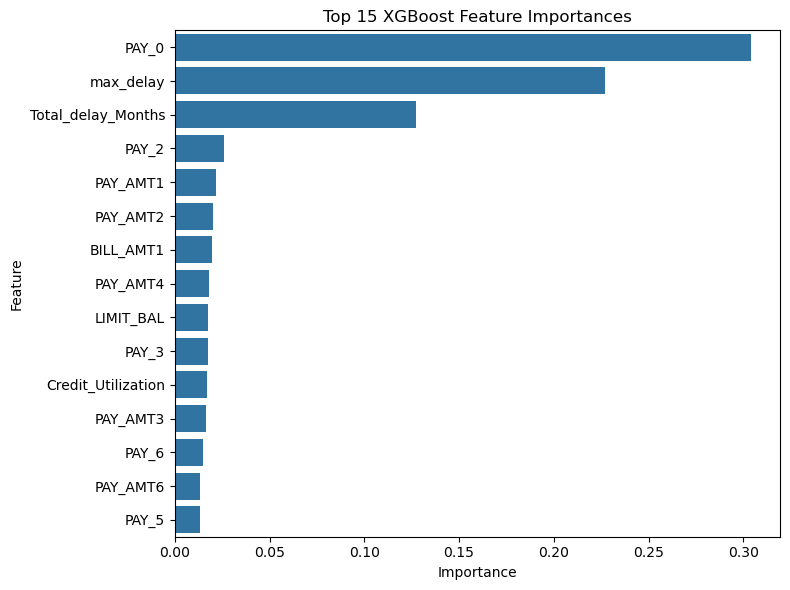

In [274]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
    y='Feature',
)

plt.title('Top 15 XGBoost Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

The top-feature plot makes it easier for me to compare the most important variables used by XGBoost. The repayment-related features are clearly more influential than many demographic variables.

### 10.Default Probability

In [275]:
final_model = xgb_search.best_estimator_

# Prepare all customer features
X_all = df_ml.drop(
    columns=['default.payment.next.month']
)

# Make sure the feature order is exactly the same
X_all = X_all[X.columns]

# Predict probability of default
df_risk = df_ml.copy()

df_risk['default_probability'] = (
    final_model.predict_proba(X_all)[:, 1]
)

df_risk[
    ['default_probability']
].head(10)

,default_probability
0,0.740906
1,0.340733
2,0.093218
3,0.143848
4,0.073969
5,0.157201
6,0.053195
7,0.137667
8,0.222072
9,0.175436


I used the tuned XGBoost model to calculate a default probability for every customer. This probability gives a more detailed risk measure than a simple default or non-default prediction.

### 11.Risk Category

In [279]:
def assign_risk(probability):

    if probability >= 0.50:
        return 'High Risk'
    elif probability >= 0.30:
        return 'Medium Risk'
    else:
        return 'Low Risk'


df_risk['risk_category'] = (
    df_risk['default_probability']
    .apply(assign_risk)
)

df_risk[
    ['default_probability', 'risk_category']
].head(10)

,default_probability,risk_category
0,0.740906,High Risk
1,0.340733,Medium Risk
2,0.093218,Low Risk
3,0.143848,Low Risk
4,0.073969,Low Risk
5,0.157201,Low Risk
6,0.053195,Low Risk
7,0.137667,Low Risk
8,0.222072,Low Risk
9,0.175436,Low Risk


I converted the predicted probabilities into three risk categories: Low Risk below 0.30, Medium Risk from 0.30 to below 0.50, and High Risk at 0.50 or above. This makes the model output easier to use for credit-limit decisions.

In [280]:
risk_counts = df_risk['risk_category'].value_counts()

print(risk_counts)

risk_category
Low Risk       23303
High Risk       3476
Medium Risk     3186
Name: count, dtype: int64


Most customers are classified as Low Risk, while smaller groups are classified as Medium Risk and High Risk. This gives me a customer-level view of the overall risk distribution.

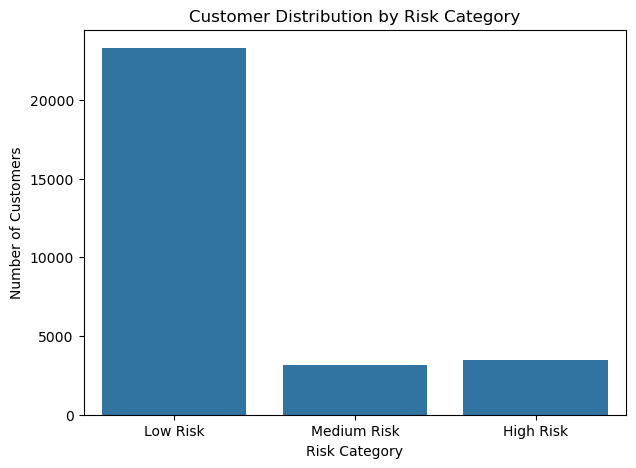

In [281]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_risk,
    x='risk_category',
    order=['Low Risk', 'Medium Risk', 'High Risk']
)

plt.title('Customer Distribution by Risk Category')
plt.xlabel('Risk Category')
plt.ylabel('Number of Customers')

plt.show()

The risk-category plot shows the number of customers in each risk group. Low Risk is the largest group, while High Risk contains a smaller but important group of customers.

### 12. Credit-Limit Recommentation

In [282]:
def recommend_credit_limit(current_limit, probability):

    if probability < 0.10:
        factor = 1.20      
    elif probability < 0.25:
        factor = 1.05      
    elif probability < 0.50:
        factor = 0.80      
    else:
        factor = 0.60     

    recommended_limit = current_limit * factor

    return round(recommended_limit, -3)


df_risk['recommended_limit'] = df_risk.apply(
    lambda row: recommend_credit_limit(
        row['LIMIT_BAL'],
        row['default_probability']
    ),
    axis=1
)

 created a simple credit-limit recommendation rule based on default probability. Lower-risk customers can receive an increase, while medium- and high-risk customers receive a reduced recommended limit.

In [283]:
df_risk[
    [
        'LIMIT_BAL',
        'default_probability',
        'risk_category',
        'recommended_limit'
    ]
].head(20)

,LIMIT_BAL,default_probability,risk_category,recommended_limit
0,20000.0,0.740906,High Risk,12000.0
1,120000.0,0.340733,Medium Risk,96000.0
2,90000.0,0.093218,Low Risk,108000.0
3,50000.0,0.143848,Low Risk,52000.0
4,50000.0,0.073969,Low Risk,60000.0
5,50000.0,0.157201,Low Risk,52000.0
6,500000.0,0.053195,Low Risk,600000.0
7,100000.0,0.137667,Low Risk,105000.0
8,140000.0,0.222072,Low Risk,147000.0
9,20000.0,0.175436,Low Risk,21000.0


### 13.Credit-Limit Recommentation Summary

In [284]:
risk_summary = df_risk.groupby('risk_category').agg(
    Customers=('LIMIT_BAL', 'count'),
    Avg_Current_Limit=('LIMIT_BAL', 'mean'),
    Avg_Recommended_Limit=('recommended_limit', 'mean'),
    Avg_Default_Probability=('default_probability', 'mean')
).reindex(
    ['Low Risk', 'Medium Risk', 'High Risk']
)

risk_summary

,Customers,Avg_Current_Limit,Avg_Recommended_Limit,Avg_Default_Probability
risk_category,,,,
Low Risk,23303,184223.219328,205482.856285,0.131550
Medium Risk,3186,123113.622097,98490.897677,0.379159
High Risk,3476,95571.346375,57342.922900,0.675428


The summary shows that Low Risk customers have the lowest average default probability and receive a higher average recommended limit. Medium and High Risk customers receive lower recommended limits as their estimated risk increases.

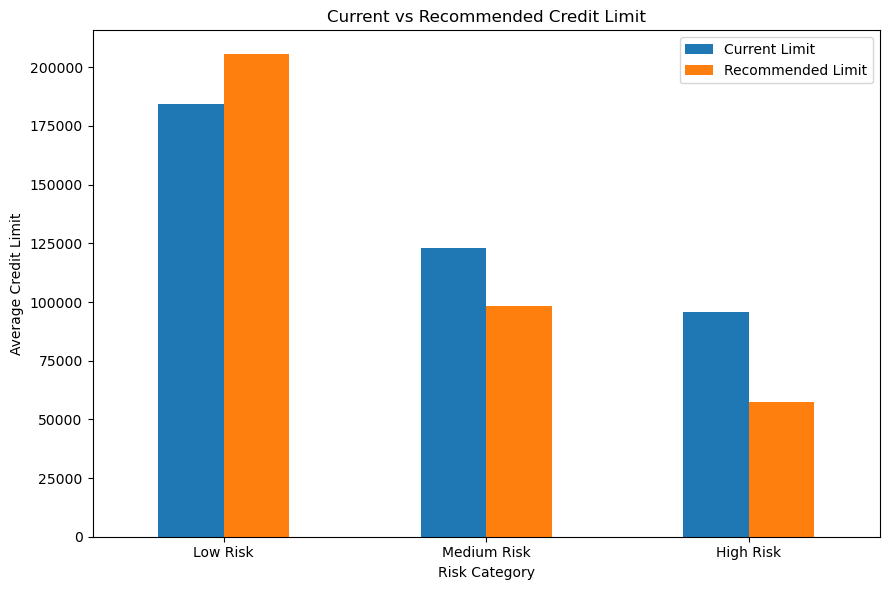

In [285]:
risk_summary[['Avg_Current_Limit', 'Avg_Recommended_Limit']].plot(
    kind='bar',
    figsize=(9, 6)
)

plt.title('Current vs Recommended Credit Limit')
plt.xlabel('Risk Category')
plt.ylabel('Average Credit Limit')
plt.xticks(rotation=0)
plt.legend(['Current Limit', 'Recommended Limit'])
plt.tight_layout()
plt.show()

### 14.Save Final Model

In [287]:
final_model = xgb_search.best_estimator_

joblib.dump(
    final_model,
    'credit_risk_xgboost_pipeline.pkl'
)

print("Final model saved successfully.")

Final model saved successfully.


 saved the final tuned XGBoost pipeline as a .pkl file so that I can load the trained model later without training it again. This will be useful when I connect the model to Streamlit.

In [288]:
final_threshold = 0.30

joblib.dump(
    final_threshold,
    'risk_threshold.pkl'
)

print("Risk threshold saved:", final_threshold)

Risk threshold saved: 0.3


 saved the final risk threshold of 0.30 separately so that the same threshold can be used when making predictions in the Streamlit application.

In [289]:
credit_limit_rules = {
    'very_low_risk': {
        'max_probability': 0.10,
        'factor': 1.20
    },
    'low_risk': {
        'max_probability': 0.25,
        'factor': 1.05
    },
    'medium_risk': {
        'max_probability': 0.50,
        'factor': 0.80
    },
    'high_risk': {
        'max_probability': 1.00,
        'factor': 0.60
    }
}

joblib.dump(
    credit_limit_rules,
    'credit_limit_rules.pkl'
)

['credit_limit_rules.pkl']

saved the credit-limit recommendation rules separately so that the same business rules can be reused in the final application.

In [290]:
joblib.dump(final_model, 'credit_risk_xgboost_pipeline.pkl')

['credit_risk_xgboost_pipeline.pkl']

In [2]:
import os 
print(os.listdir())

['.ipynb_checkpoints', 'Credit_Limit.ipynb', 'Credit_limit_optizmation.ipynb', 'credit_limit_rules.pkl', 'credit_risk_xgboost_pipeline.pkl', 'Final_Project (1).ipynb', 'risk_threshold.pkl', 'UCI_Credit_Card.csv.zip']


In [ ]:
import 